# 360° Digital Marketing Performance Audit
#### **Context**
This analysis is based on simulated digital marketing campaign data for three
major Indian beauty e-commerce brands : Nykaa, Purplle and Tira Beauty.
The dataset covers multiple channels, campaign types, customer segments and languages.

#### **Business Problem**
How are Nykaa, Purplle and Tira Beauty performing across their digital marketing
campaigns, and where does each brand have optimization opportunities ?

#### **Objectives**
The goal of this analysis is to :
1. Evaluate acquisition & reach efficiency by channel and brand
2. Assess conversion and revenue performance by campaign type and customer segment
3. Benchmark cost efficiency across brands and channels
4. Understand audience engagement patterns by segment and language
5. Analyze time performance and detect seasonality or campaign peaks

#### **KPIs of Focus**
- CTR (Click-Through Rate) = Clicks / Impressions
- CVR (Conversion Rate) = Conversions / Clicks
- CPL (Cost per Lead) = Acquisition_Cost / Leads
- ROI, Revenue, Engagement_Score

#### **1- Setup & Data Loading**
This section covers library imports, data loading, individual file verification,
merging and data type fixing as well as feature engineering.

In [22]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
# Loading each brand's campaign data from separate CSV files

df_nykaa = pd.read_csv("/content/drive/MyDrive/Data projects/Multi-Brand Marketing Campaign/nykaa_campaign_data.csv")
df_purplle = pd.read_csv("/content/drive/MyDrive/Data projects/Multi-Brand Marketing Campaign/purplle_campaign_data.csv")
df_tira = pd.read_csv("/content/drive/MyDrive/Data projects/Multi-Brand Marketing Campaign/tira_campaign_data.csv")

# Quick verification function
def check_df(df, name):
    print(f"{'-'*40}")
    print(f"Brand : {name}")
    print(f"Shape : {df.shape}")
    print(f"Columns : {df.columns.tolist()}")
    print(f"Missing values : {df.isnull().sum().sum()}")
    print(f"Duplicates : {df.duplicated().sum()}")
    print(f"\nFirst row :")
    print(df.head(1))
    print()

check_df(df_nykaa, "Nykaa")
check_df(df_purplle, "Purplle")
check_df(df_tira, "Tira Beauty")



----------------------------------------
Brand : Nykaa
Shape : (55555, 16)
Columns : ['Campaign_ID', 'Campaign_Type', 'Target_Audience', 'Duration', 'Channel_Used', 'Impressions', 'Clicks', 'Leads', 'Conversions', 'Revenue', 'Acquisition_Cost', 'ROI', 'Language', 'Engagement_Score', 'Customer_Segment', 'Date']
Missing values : 0
Duplicates : 0

First row :
   Campaign_ID Campaign_Type   Target_Audience  Duration       Channel_Used  \
0  NY-CMP-1000  Social Media  College Students        21  WhatsApp, YouTube   

   Impressions  Clicks  Leads  Conversions  Revenue  Acquisition_Cost   ROI  \
0        57804    6156   3616         2355  1867515            111.03  6.14   

  Language  Engagement_Score  Customer_Segment        Date  
0    Hindi             20.98  College Students  29-04-2025  

----------------------------------------
Brand : Purplle
Shape : (55555, 16)
Columns : ['Campaign_ID', 'Campaign_Type', 'Target_Audience', 'Duration', 'Channel_Used', 'Impressions', 'Clicks', 'Leads',

➡️ All three dataset have 55555 rows and 16 columns with no missing values and no duplicates. They seem to have the exact same columns and we will confirm it.

In [24]:
# Checking if columns are identical across all 3 files
assert df_nykaa.columns.tolist() == df_purplle.columns.tolist() == df_tira.columns.tolist(), \
    "Column mismatch between files !"
print("All columns are consistent across files.")

All columns are consistent across files.


➡️ Since all 3 files look correct and consistent, we proceed to the merge.

In [25]:
# Adding a 'Brand' column to each dataset
df_nykaa["Brand"] = "Nykaa"
df_purplle["Brand"] = "Purplle"
df_tira["Brand"] = "Tira Beauty"

# Stacking them vertically
df = pd.concat([df_nykaa, df_purplle, df_tira], ignore_index=True)

# Verifying merge integrity
print("Expected rows :", len(df_nykaa) + len(df_purplle) + len(df_tira))
print("Actual rows after merge :", len(df))
print("Match :", len(df) == len(df_nykaa) + len(df_purplle) + len(df_tira))

# Confirming all 3 brands are present
print("\nBrands in dataset :\n", df["Brand"].value_counts())

df.head(5)

Expected rows : 166665
Actual rows after merge : 166665
Match : True

Brands in dataset :
 Brand
Nykaa          55555
Purplle        55555
Tira Beauty    55555
Name: count, dtype: int64


,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date,Brand
0,NY-CMP-1000,Social Media,College Students,21,"WhatsApp, YouTube",57804,6156,3616,2355,1867515,111.03,6.14,Hindi,20.98,College Students,29-04-2025,Nykaa
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18,YouTube,91801,3321,1971,1357,1046247,180.83,3.26,Hindi,7.24,College Students,06-04-2025,Nykaa
2,NY-CMP-1002,Influencer,Youth,23,"WhatsApp, Google, YouTube",15536,2182,952,755,197055,90.60,1.88,English,25.03,College Students,14-01-2025,Nykaa
3,NY-CMP-1003,Email,Working Women,18,"YouTube, Facebook, Instagram",88114,8413,2231,947,376906,249.07,0.60,Hindi,13.15,College Students,04-06-2025,Nykaa
4,NY-CMP-1004,Paid Ads,College Students,10,"Facebook, Instagram",96871,3743,2060,1258,518296,228.60,0.80,Hindi,7.29,Tier 2 City Customers,29-12-2024,Nykaa


➡️ This confirms the merge was successful and no rows were lost or duplicated during the concat.
Let's verify the data types.

In [26]:
# Standardizing column names to lowercase with underscores for consistency
df.columns = df.columns.str.lower().str.replace(" ", "_")
print("Renamed columns :\n", df.columns.tolist())

Renamed columns :
 ['campaign_id', 'campaign_type', 'target_audience', 'duration', 'channel_used', 'impressions', 'clicks', 'leads', 'conversions', 'revenue', 'acquisition_cost', 'roi', 'language', 'engagement_score', 'customer_segment', 'date', 'brand']


In [27]:
# Inspecting data types to identify what actually needs changing
print (df.dtypes)

campaign_id          object
campaign_type        object
target_audience      object
duration              int64
channel_used         object
impressions           int64
clicks                int64
leads                 int64
conversions           int64
revenue               int64
acquisition_cost    float64
roi                 float64
language             object
engagement_score    float64
customer_segment     object
date                 object
brand                object
dtype: object


➡️ Let's convert:

- `date` : object → datetime to enable time-based analysis
- `revenue` : int → float to allow decimal precision in calculations

In [28]:
# Fixing data types to ensure accurate analysis

# Date
df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y")

# Revenue
df["revenue"] = df["revenue"].astype("float64")

print("Updated data types :\n", df.dtypes)

# Confirm type conversion didn't introduce unexpected nulls or invalid dates
print(f"\nNulls after type fixing :{df[["revenue", "date"]].isnull().sum()}")
print(f"\nDate range : {df['date'].min().date()} to {df['date'].max().date()}")

Updated data types :
 campaign_id                 object
campaign_type               object
target_audience             object
duration                     int64
channel_used                object
impressions                  int64
clicks                       int64
leads                        int64
conversions                  int64
revenue                    float64
acquisition_cost           float64
roi                        float64
language                    object
engagement_score           float64
customer_segment            object
date                datetime64[ns]
brand                       object
dtype: object

Nulls after type fixing :revenue    0
date       0
dtype: int64

Date range : 2024-07-01 to 2025-06-24


➡️ The dataset covers ~12 months : July 2024 to June 2025. That will enable analysis such as seasonality or semester-over-semester comparisons.

Proceeding to feature engineering.

In [29]:
# Exploring channel_used to detect multi-channel campaigns
df["channel_used"].value_counts().head(10)

,count
channel_used,
Email,9413
Instagram,9300
Facebook,9261
Google,9198
YouTube,9182
WhatsApp,9169
"YouTube, Instagram",1935
"WhatsApp, Google",1922
"Email, Facebook",1918


➡️ The initial exploration of the `channel_used` column revealed that some campaigns leverage multiple marketing channels simultaneously. This distinction between single-channel and multi-channel campaigns is important, as it may significantly impact performance metrics such as ROI, conversions, and engagement.

In [30]:
# Feature engineering

# Creating channel_type column to distinguish single vs multi-channel campaigns
df["channel_type"] = df["channel_used"].apply(
    lambda x: "Multi-Channel" if "," in x else "Single-Channel"
)

# Creating derived marketing metrics for deeper performance analysis
df["ctr"] = (df["clicks"] / df["impressions"] * 100).round(2)       # Click-Through Rate (%)
df["cvr"] = (df["conversions"] / df["clicks"] * 100).round(2)       # Conversion Rate (%)

print("New columns added :", ["channel_type", "ctr", "cvr"])
print(df[["channel_type", "ctr", "cvr"]].head(5))

New columns added : ['channel_type', 'ctr', 'cvr']
     channel_type    ctr    cvr
0   Multi-Channel  10.65  38.26
1  Single-Channel   3.62  40.86
2   Multi-Channel  14.04  34.60
3   Multi-Channel   9.55  11.26
4   Multi-Channel   3.86  33.61


➡️ These derived variables will be used throughout the analysis :
- `channel_type` — distinguishes single vs multi-channel campaign strategies
- `ctr` — measures reach efficiency (how many impressions convert to clicks)
- `cvr` — measures conversion efficiency (how many clicks convert to sales)


---
📌 Our dataset is now clean and ready for quality analysis.

#### **2- Data Quality Check**

Before analyzing the data, let's assess its quality and reliability.
This section covers missing values, duplicates, statistical summary and outlier detection.

In [31]:
# Verifying campaign_id is a unique identifier across the merged dataset
total_rows = len(df)
unique_ids = df["campaign_id"].nunique()

print(f"Total rows : {total_rows}")
print(f"Unique campaign_ids : {unique_ids}")
print(f"campaign_id is unique : {total_rows == unique_ids}")

Total rows : 166665
Unique campaign_ids : 166665
campaign_id is unique : True


➡️ Missing values and duplicates were already verified at the individual file level in Section 1 and none were found across all 3 datasets.

Since `campaign_id` was confirmed as unique identifier, cross-file duplicates are structurally impossible.

Proceeding directly to statistical summary and outlier detection.


In [32]:
# Statistical Summary
# High-level overview of numeric columns

df.describe().round(2)

,duration,impressions,clicks,leads,conversions,revenue,acquisition_cost,roi,engagement_score,date,ctr,cvr
count,166665.00,166665.00,166665.00,166665.00,166665.00,166665.00,166665.00,166665.00,166665.00,166665,166665.00,166665.00
mean,17.49,55060.85,4682.37,1871.51,1029.09,513906.62,376.09,2.69,13.77,2024-12-20 16:12:39.463594496,8.50,21.95
min,5.00,10001.00,202.00,48.00,17.00,3895.00,8.18,-0.99,2.56,2024-07-01 00:00:00,2.00,5.92
25%,11.00,32566.00,2109.00,779.00,401.00,177661.00,106.73,0.04,8.38,2024-09-25 00:00:00,5.26,15.24
50%,17.00,55110.00,3904.00,1476.00,776.00,359250.00,208.51,1.23,13.59,2024-12-21 00:00:00,8.50,20.51
75%,24.00,77574.00,6688.00,2598.00,1404.00,684797.00,427.57,3.58,18.79,2025-03-17 00:00:00,11.77,27.75
max,30.00,100000.00,14944.00,8876.00,6686.00,4579910.00,15473.16,79.30,30.99,2025-06-24 00:00:00,15.00,47.87
std,7.50,25970.65,3176.50,1429.59,858.01,487644.25,534.94,4.48,6.33,NaN,3.75,8.73


**➡️ Key observations from statistical summary :**
- *Skewed distributions* : revenue (mean 513k > median 359k) and acquisition_cost (std exceeds mean) suggest right-skewed distributions with high-end extreme values
- *Loss-making campaigns exist* : ROI minimum is negative (-0.99) — realistic in a marketing context
- *Logical funnel progression confirmed* : impressions → clicks → leads →
  conversions show consistent scale reduction as expected
- *No structural anomalies* : duration, engagement_score and date ranges all fall within plausible bounds
- *Derived metrics* : CTR ranges from 2% to 15% (mean 8.5%), plausible for digital campaigns. CVR mean of 21.9% is atypically high compared to real-world benchmarks, reflecting the simulated nature of the dataset


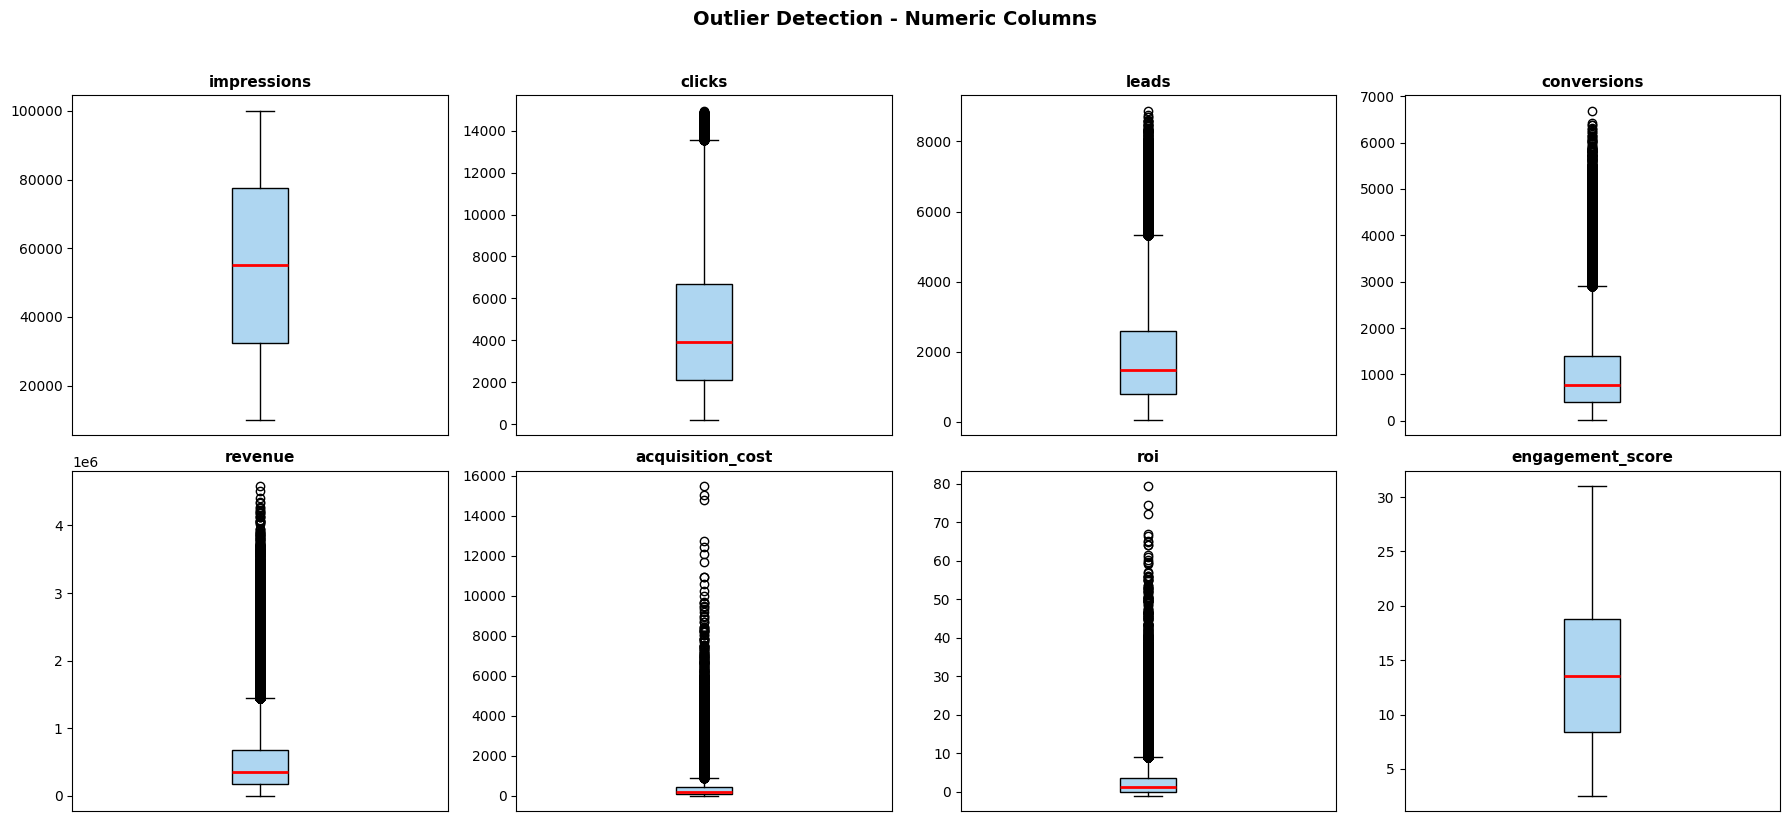

In [33]:
# Visualizing distributions to detect outliers
# Using boxplots to identifying spread, skewness and extreme values

numeric_cols = ["impressions", "clicks", "leads", "conversions",
                "revenue", "acquisition_cost", "roi", "engagement_score"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor="#AED6F1"),
                    medianprops=dict(color="red", linewidth=2))
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].tick_params(axis="x", which="both", bottom=False, labelbottom=False)

plt.suptitle("Outlier Detection - Numeric Columns", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**➡️ Outlier detection confirms :**
- `impressions` and `engagement_score` are cleanly distributed with no significant outliers
- `clicks`, `leads` and `conversions` show consistent upper tails — high-performing campaigns exist but are not extreme
- `revenue`, `acquisition_cost` and `roi` show significant high-end outliers, confirming the skewed distributions identified in the statistical summary
- `roi` shows outliers on both ends - loss-making campaigns (negative ROI) and exceptionally high-performing ones coexist in the dataset

These outliers are not errors, they reflect natural performance variance in digital marketing campaigns and will be analyzed in depth in Section 5.

---
📌 Dataset is confirmed clean and reliable. No missing values, no duplicates,
no structural anomalies.

Proceeding to exploratory analysis.

#### **3- Univariate Analysis**

Let's examine the distribution of each variable independently to understand
the shape, spread and frequency of values before exploring relationships.
This section covers numeric distributions and categorical frequencies.



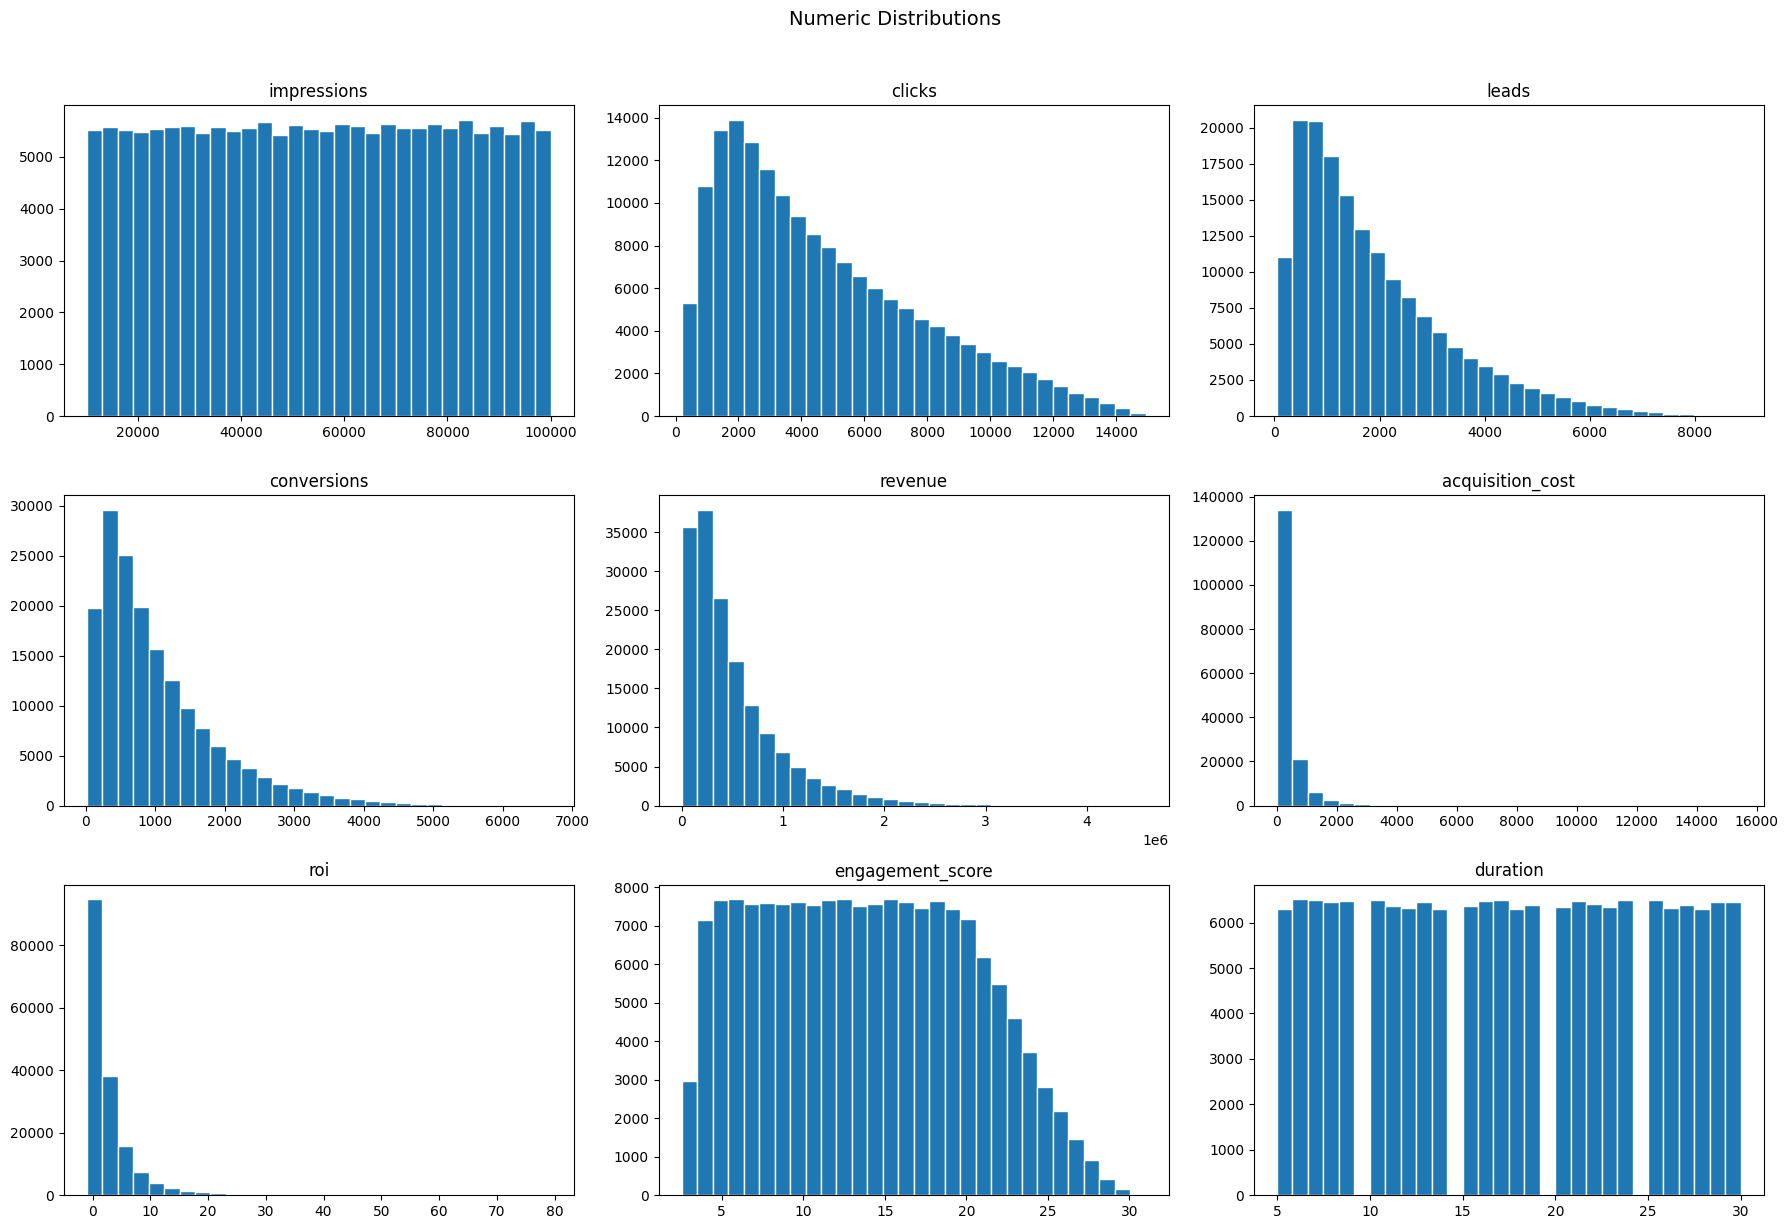

In [34]:
# Visualizing numeric distributions to confirm skewness patterns observed in the statistical summary

numeric_cols = ["impressions", "clicks", "leads", "conversions",
                "revenue", "acquisition_cost", "roi", "engagement_score", "duration"]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_xlabel("")

plt.suptitle("Numeric Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**➡️ Key Findings :**

Numeric distributions :
- `impressions` and `duration` are uniformly distributed, campaigns are
  evenly spread across reach levels and lengths by design
- `clicks`, `leads`, `conversions`, `revenue` and `acquisition_cost` are right-skewed, most campaigns cluster at lower values with a long tail of high performers, consistent with Section 2 outlier findings
- `acquisition_cost` shows an extremely steep distribution,
  the vast majority of campaigns have low acquisition costs,
  with rare but significant extreme values
- `roi` confirms the same pattern, majority of campaigns cluster near 0 with exceptional outliers on the high end
- `engagement_score` follows a roughly normal distribution, peaking between 5 and 25.

The histograms reveal clear patterns across numeric variables.
Let's quantify skewness to confirm these visual observations.

In [35]:
# Quantifying skewness of numeric distributions
# > 1 or < -1 : highly skewed | 0.5 to 1 : moderately skewed | < 0.5 : approximately symmetric
print(df[numeric_cols].skew().round(2))

impressions        -0.00
clicks              0.82
leads               1.25
conversions         1.59
revenue             2.06
acquisition_cost    5.42
roi                 3.53
engagement_score    0.17
duration            0.00
dtype: float64


➡️ Skewness confirmed numerically :
- `impressions`, `duration` : 0.00 → perfectly uniform by design
- `engagement_score` : 0.17 → approximately symmetric
- `clicks` : 0.82 → moderately right-skewed
- `leads` (1.25), `conversions` (1.59), `revenue` (2.06),
  `roi` (3.53) → highly right-skewed
- `acquisition_cost` : 5.42 → extremely right-skewed,
  distribution heavily concentrated at low values
  with rare but significant extreme costs

➡️ All categorical variables are perfectly balanced by design (simulated dataset).

We can confirm frequencies numerically, no bar charts are needed.

In [36]:
# Categorical Summary - Counting frequency
cat_cols = ["campaign_type", "channel_used", "customer_segment",
            "language", "brand"]

for col in cat_cols:
    print(f"\n{col} :\n", df[col].value_counts(normalize=True).round(2))


campaign_type :
 campaign_type
Influencer      0.2
Email           0.2
Paid Ads        0.2
SEO             0.2
Social Media    0.2
Name: proportion, dtype: float64

channel_used :
 channel_used
Email                           0.06
Instagram                       0.06
Facebook                        0.06
Google                          0.06
YouTube                         0.06
                                ... 
Email, Instagram, WhatsApp      0.00
YouTube, WhatsApp, Instagram    0.00
Email, Google, YouTube          0.00
Email, YouTube, Facebook        0.00
Instagram, Facebook, YouTube    0.00
Name: proportion, Length: 156, dtype: float64

customer_segment :
 customer_segment
Youth                    0.2
College Students         0.2
Working Women            0.2
Tier 2 City Customers    0.2
Premium Shoppers         0.2
Name: proportion, dtype: float64

language :
 language
Hindi      0.25
Tamil      0.25
Bengali    0.25
English    0.25
Name: proportion, dtype: float64

brand :
 brand
N

➡️ `channel_used` showed 156 unique values, let's investigate the single vs multi-channel structure identified during feature engineering.

In [37]:
# Investigating channel_used
print(f"Unique channel values : {df['channel_used'].nunique()}")
print(f"\nSample of multi-channel values :")
print(df[df['channel_used'].str.contains(',')]['channel_used'].value_counts().head(10))
print(f"\nSingle channel values :")
print(df[~df['channel_used'].str.contains(',')]['channel_used'].value_counts())

Unique channel values : 156

Sample of multi-channel values :
channel_used
YouTube, Instagram     1935
WhatsApp, Google       1922
Email, Facebook        1918
YouTube, WhatsApp      1904
Email, Google          1897
Google, Instagram      1890
Google, Facebook       1889
Instagram, YouTube     1881
Email, WhatsApp        1880
WhatsApp, Instagram    1875
Name: count, dtype: int64

Single channel values :
channel_used
Email        9413
Instagram    9300
Facebook     9261
Google       9198
YouTube      9182
WhatsApp     9169
Name: count, dtype: int64


channel_type
Multi-Channel     111142
Single-Channel     55523
Name: count, dtype: int64
channel_type
Multi-Channel     0.67
Single-Channel    0.33
Name: proportion, dtype: float64


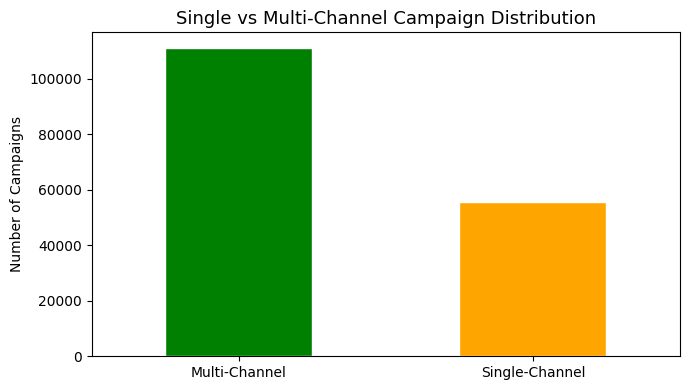

In [38]:
# Analyzing single vs multi-channel campaign split
print(df["channel_type"].value_counts())
print(df["channel_type"].value_counts(normalize=True).round(2))

# Visualizing the split
df["channel_type"].value_counts().plot(
    kind="bar",
    color=["green", "orange"],
    edgecolor="white",
    figsize=(7, 4)
)

plt.title("Single vs Multi-Channel Campaign Distribution", fontsize=13)
plt.xlabel("")
plt.xticks(rotation=0)
plt.ylabel("Number of Campaigns")
plt.tight_layout()
plt.show()

➡️ Categorical variables :
- `channel_used` contains 156 unique combinations of 6 base channels
- 67% of campaigns are multi-channel vs 33% single-channel, a key strategic variable to explore in Section 4.

---
📌 Having understood the individual distributions of each variable,
we now explore relationships between them to identify performance drivers.


#### **4- Bivariate Analysis**
We explore relationships between variables to identify patterns,
correlations and performance drivers.

This section covers correlation analysis and key variable relationships aligned with our 360° audit objectives.

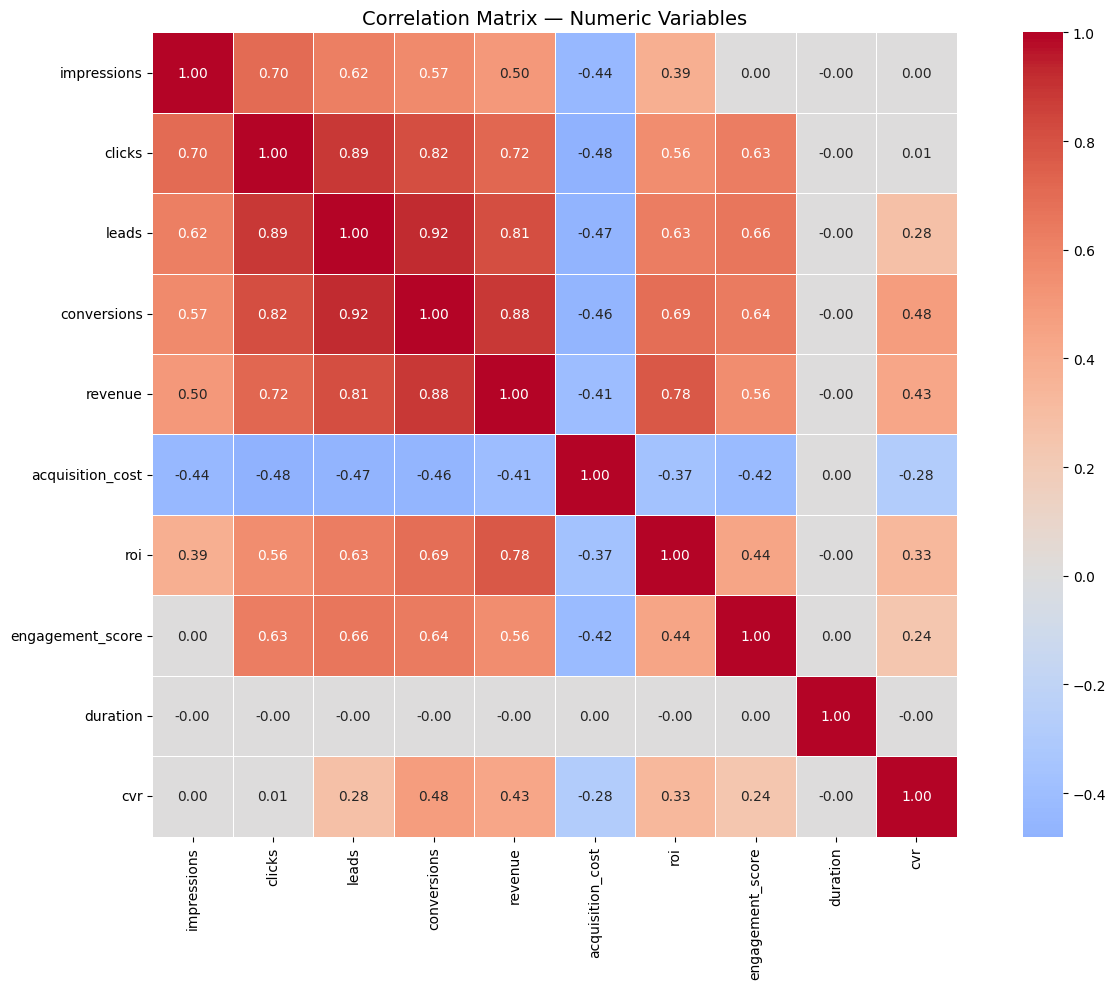

In [39]:
# Correlation heatmap to identify relationships between numeric variables
# Provides a global view of how performance metrics relate to each other

numeric_cols = ["impressions", "clicks", "leads", "conversions",
                "revenue", "acquisition_cost", "roi",
                "engagement_score", "duration", "cvr"]

corr_matrix = df[numeric_cols].corr().round(2)

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix — Numeric Variables", fontsize=14)
plt.tight_layout()
plt.show()

**➡️ Correlation findings :**
- Strong funnel coherence : clicks → leads → conversions → revenue
  are highly correlated (0.82—0.92), confirming a consistent conversion pipeline
- Revenue is the strongest predictor of ROI (0.78) — volume drives returns
- Engagement score correlates meaningfully with clicks, leads and conversions
  (0.63—0.66) — audience engagement is a key performance driver
- Acquisition cost is negatively correlated with all performance metrics
  (-0.41 to -0.48) — higher spend campaigns consistently underperform
- Duration shows zero correlation with all metrics — campaign length
  has no impact on performance
- Impressions → ROI correlation is weak (0.39) — reach alone does not drive returns, engagement quality matters more

/tmp/ipykernel_6559/3633937264.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="campaign_type", y="roi",


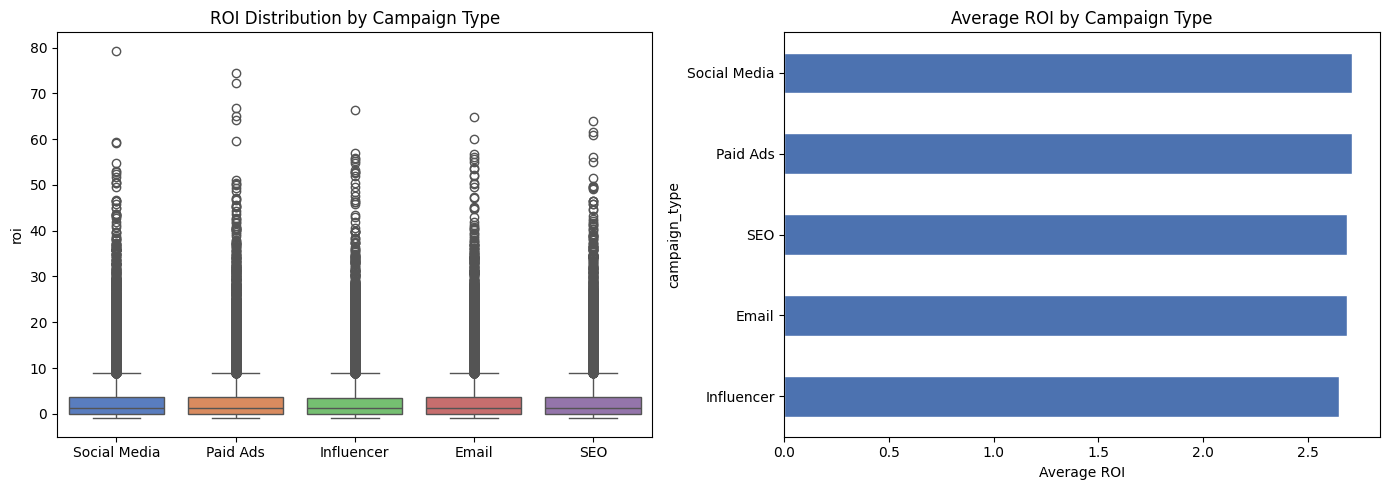

campaign_type
Paid Ads        2.71
Social Media    2.71
Email           2.69
SEO             2.69
Influencer      2.65
Name: roi, dtype: float64


In [40]:
# ROI distribution across campaign types
# Identifies which campaign strategy delivers the best return on investment

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="campaign_type", y="roi",
            palette="muted", ax=axes[0])
axes[0].set_title("ROI Distribution by Campaign Type")
axes[0].set_xlabel("")

df.groupby("campaign_type")["roi"].mean().round(2)\
    .sort_values(ascending=True)\
    .plot(kind="barh", ax=axes[1], color="#4C72B0", edgecolor="white")
axes[1].set_title("Average ROI by Campaign Type")
axes[1].set_xlabel("Average ROI")

plt.tight_layout()
plt.show()

print(df.groupby("campaign_type")["roi"].mean().round(2).sort_values(ascending=False))

/tmp/ipykernel_6559/313814065.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="campaign_type", y="cvr",


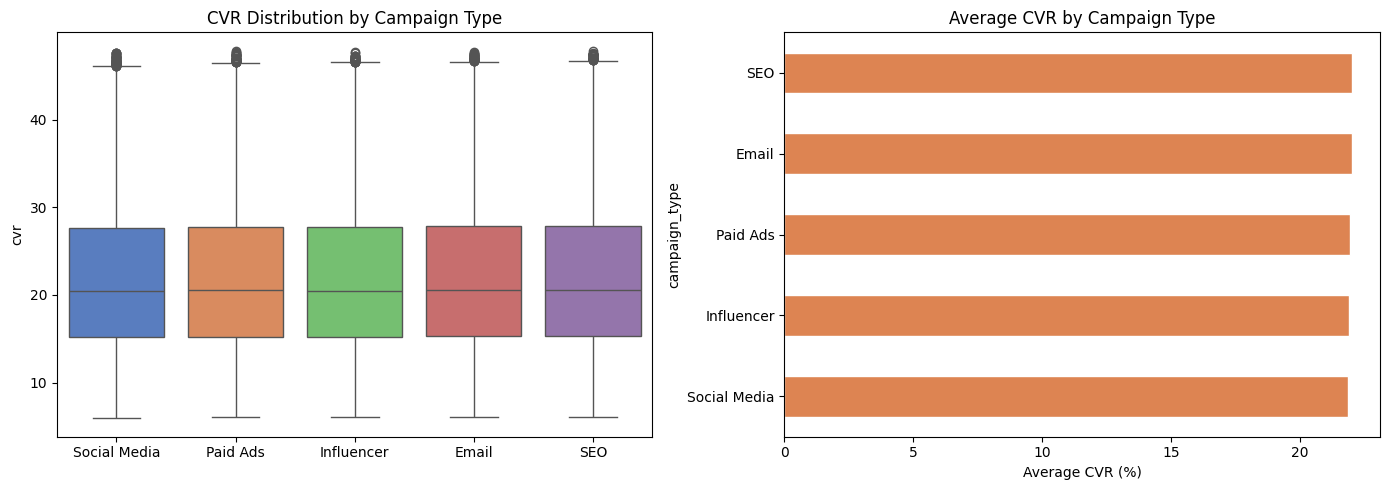

campaign_type
Email           22.00
SEO             22.00
Paid Ads        21.95
Influencer      21.91
Social Media    21.87
Name: cvr, dtype: float64


In [42]:
# Conversion rate across campaign types
# CVR complements ROI — a campaign can have high ROI with low volume
# or high CVR with modest revenue

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="campaign_type", y="cvr",
            palette="muted", ax=axes[0])
axes[0].set_title("CVR Distribution by Campaign Type")
axes[0].set_xlabel("")

df.groupby("campaign_type")["cvr"].mean().round(2)\
    .sort_values(ascending=True)\
    .plot(kind="barh", ax=axes[1], color="#DD8452", edgecolor="white")
axes[1].set_title("Average CVR by Campaign Type")
axes[1].set_xlabel("Average CVR (%)")

plt.tight_layout()
plt.show()

print(df.groupby("campaign_type")["cvr"].mean().round(2).sort_values(ascending=False))

/tmp/ipykernel_6559/4076161563.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="channel_type", y="roi",
/tmp/ipykernel_6559/4076161563.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="channel_type", y="cvr",


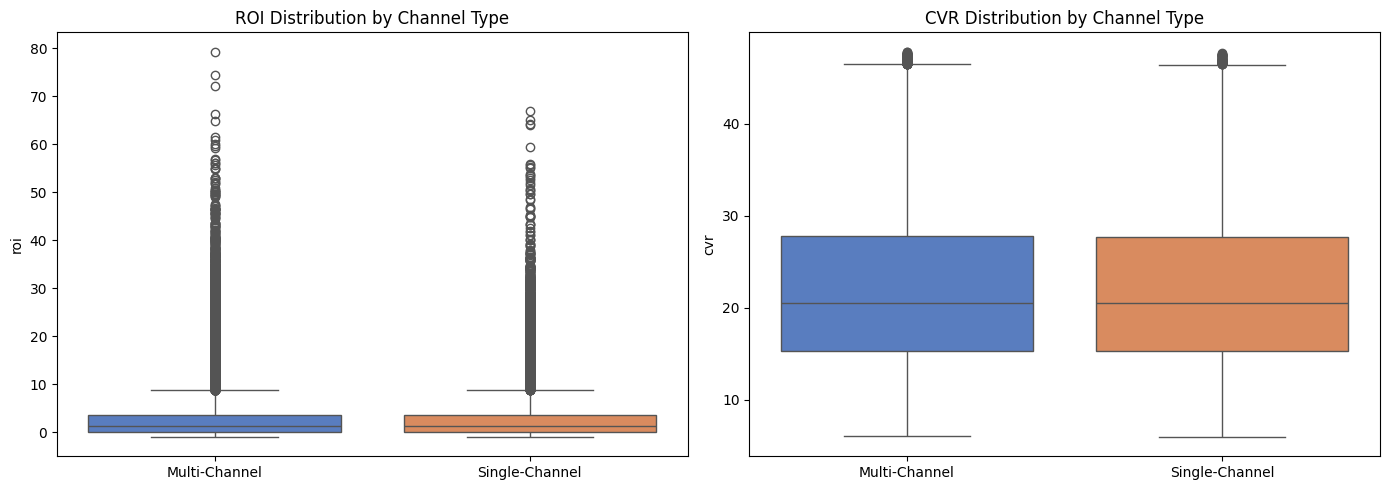

                 roi    cvr
channel_type               
Multi-Channel   2.70  21.95
Single-Channel  2.68  21.93


In [41]:
# ROI comparison between single and multi-channel campaigns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="channel_type", y="roi",
            palette="muted", ax=axes[0])
axes[0].set_title("ROI Distribution by Channel Type")
axes[0].set_xlabel("")

sns.boxplot(data=df, x="channel_type", y="cvr",
            palette="muted", ax=axes[1])
axes[1].set_title("CVR Distribution by Channel Type")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

print(df.groupby("channel_type")[["roi", "cvr"]].mean().round(2))

/tmp/ipykernel_6559/3221215350.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="customer_segment", y="revenue",


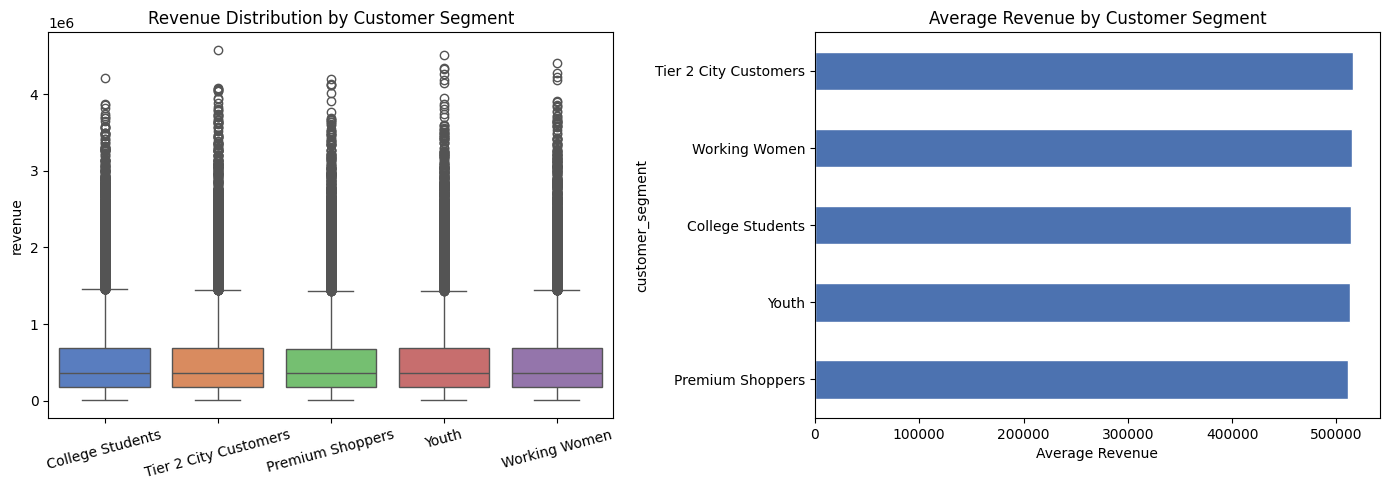

customer_segment
Tier 2 City Customers    515934.32
Working Women            515219.93
College Students         514217.25
Youth                    513317.69
Premium Shoppers         510833.39
Name: revenue, dtype: float64


In [43]:
# Revenue distribution across customer segments
# Identifies highest value segments for targeting optimization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="customer_segment", y="revenue",
            palette="muted", ax=axes[0])
axes[0].set_title("Revenue Distribution by Customer Segment")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=15)

df.groupby("customer_segment")["revenue"].mean().round(2)\
    .sort_values(ascending=True)\
    .plot(kind="barh", ax=axes[1], color="#4C72B0", edgecolor="white")
axes[1].set_title("Average Revenue by Customer Segment")
axes[1].set_xlabel("Average Revenue")

plt.tight_layout()
plt.show()

print(df.groupby("customer_segment")["revenue"].mean().round(2).sort_values(ascending=False))

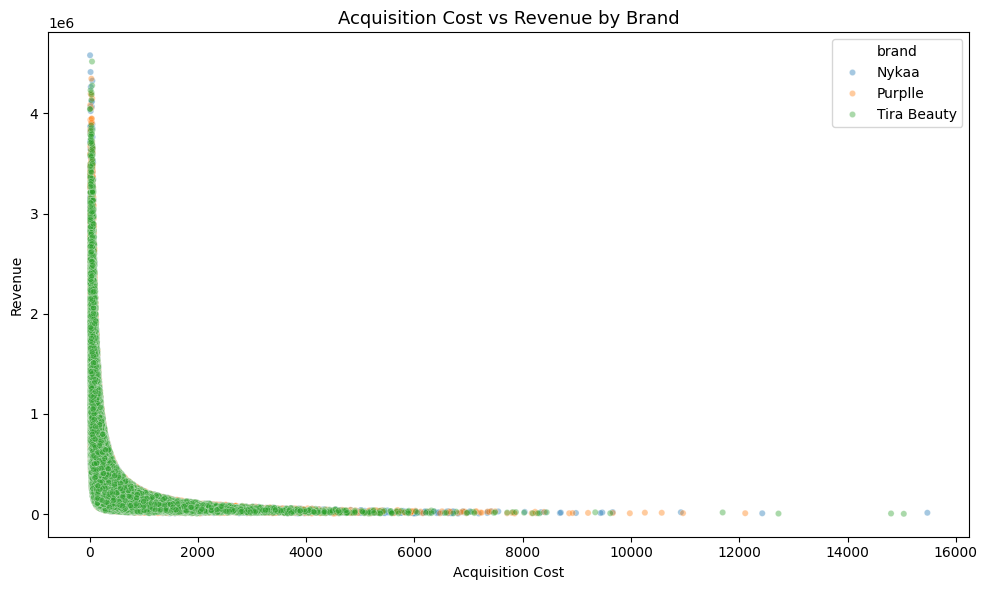

Correlation between acquisition_cost and revenue : -0.406


In [44]:
# Scatterplot of acquisition cost vs revenue colored by brand
# Assessing cost efficiency — are higher spend campaigns
# generating proportional returns ?

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="acquisition_cost",
    y="revenue",
    hue="brand",
    alpha=0.4,
    s=20
)

plt.title("Acquisition Cost vs Revenue by Brand", fontsize=13)
plt.xlabel("Acquisition Cost")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

# Correlation between acquisition cost and revenue
corr = df["acquisition_cost"].corr(df["revenue"]).round(3)
print(f"Correlation between acquisition_cost and revenue : {corr}")

📌 Having identified key relationships and performance drivers across variables, we now conduct a full comparative analysis across the three brands.

#### **5- 360° Brand Analysis**

#### **6- Key Findings & Recommendations**